In [ ]:
import numpy as np                                                                        
import matplotlib.pyplot as plt
import pyCloudy as pc
import pyneb as pn
from astropy    import constants as const
from astropy.io import ascii
import pandas as pd
from scipy import interpolate
import warnings
from scipy.integrate import quad, IntegrationWarning
import scipy.integrate as integrate
from numpy import log10, exp
import os
from astropy.constants import h, c, k_B, kpc
import astropy.units as u
from scipy import special
import warnings
from scipy.interpolate import interp1d
import matplotlib.gridspec as gridspec
warnings.filterwarnings('ignore', category=IntegrationWarning)
kpc = const.kpc.cgs.value
h_ev = h.to(u.eV *u.s).value
c_cms = c.to(u.cm/u.s).value
c_kms = c.to(u.km/u.s).value
Ly_a_K = 1215.673644609e-8
Ly_a_H = 1215.668237310e-8
C_IV_K = 1548.187e-8
C_IV_H = 1550.772e-8

In [25]:
Lumin = 44.0 # Lumin = 44.0, 45.5
idx = 2 # 1 -> on line transfer 2-> no line transfer, 3- > no induced processes (no continuum pumping)
metals = 1.0 # 0.001,0.01,0.1,1.0,10.0
multi_factor = 1.0 # 1.0 , 3.2
Column_density_order = 22.0 
mode = 'WO' # W -> masking , WO - > no masking

In [26]:
from CLOUDY_Function import path, CLOUDY_data , CLOUDY_data_path

path_civ = path(Lumin,idx,metals,Column_density_order)
output = CLOUDY_data(Lumin,idx,metals,Column_density_order)


In [27]:
# path_nufnu = f"/home/jin/RT/Test_CLOUDY/tt/QSO_nufnu"
# path_fnu = f"/home/jin/RT/Test_CLOUDY/tt/QSO_fnu"

# nufnu = CLOUDY_data_path(path_nufnu)
# fnu = CLOUDY_data_path(path_fnu)


In [28]:
# plt.plot(nufnu['radius'],nufnu['frac_HII'],'r-')
# plt.plot(fnu['radius'],fnu['frac_HII'],'b--')
# # plt.yscale('log')

In [29]:

def Flux(Fc,F_max,lam,lam_c,sig_vel):
    del_lam = sig_vel / c_kms  * lam_c
    Flux = (F_max-Fc)*np.exp(- (lam-lam_c)**2 / del_lam**2) + Fc
    return Flux
def EW(Fc,F_max,lam_c,sig_vel):
    del_lam = sig_vel / c_kms  * lam_c
    EW =(F_max/ Fc)*np.sqrt(np.pi)*del_lam
    return EW

def Ryd_to_lam(Ryd_x):
    lambda_x = c_cms /  (Ryd_x * 13.6 /h_ev) *1e8

/tmp/ipykernel_3415/157592528.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_3415/157592528.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_3415/157592528.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


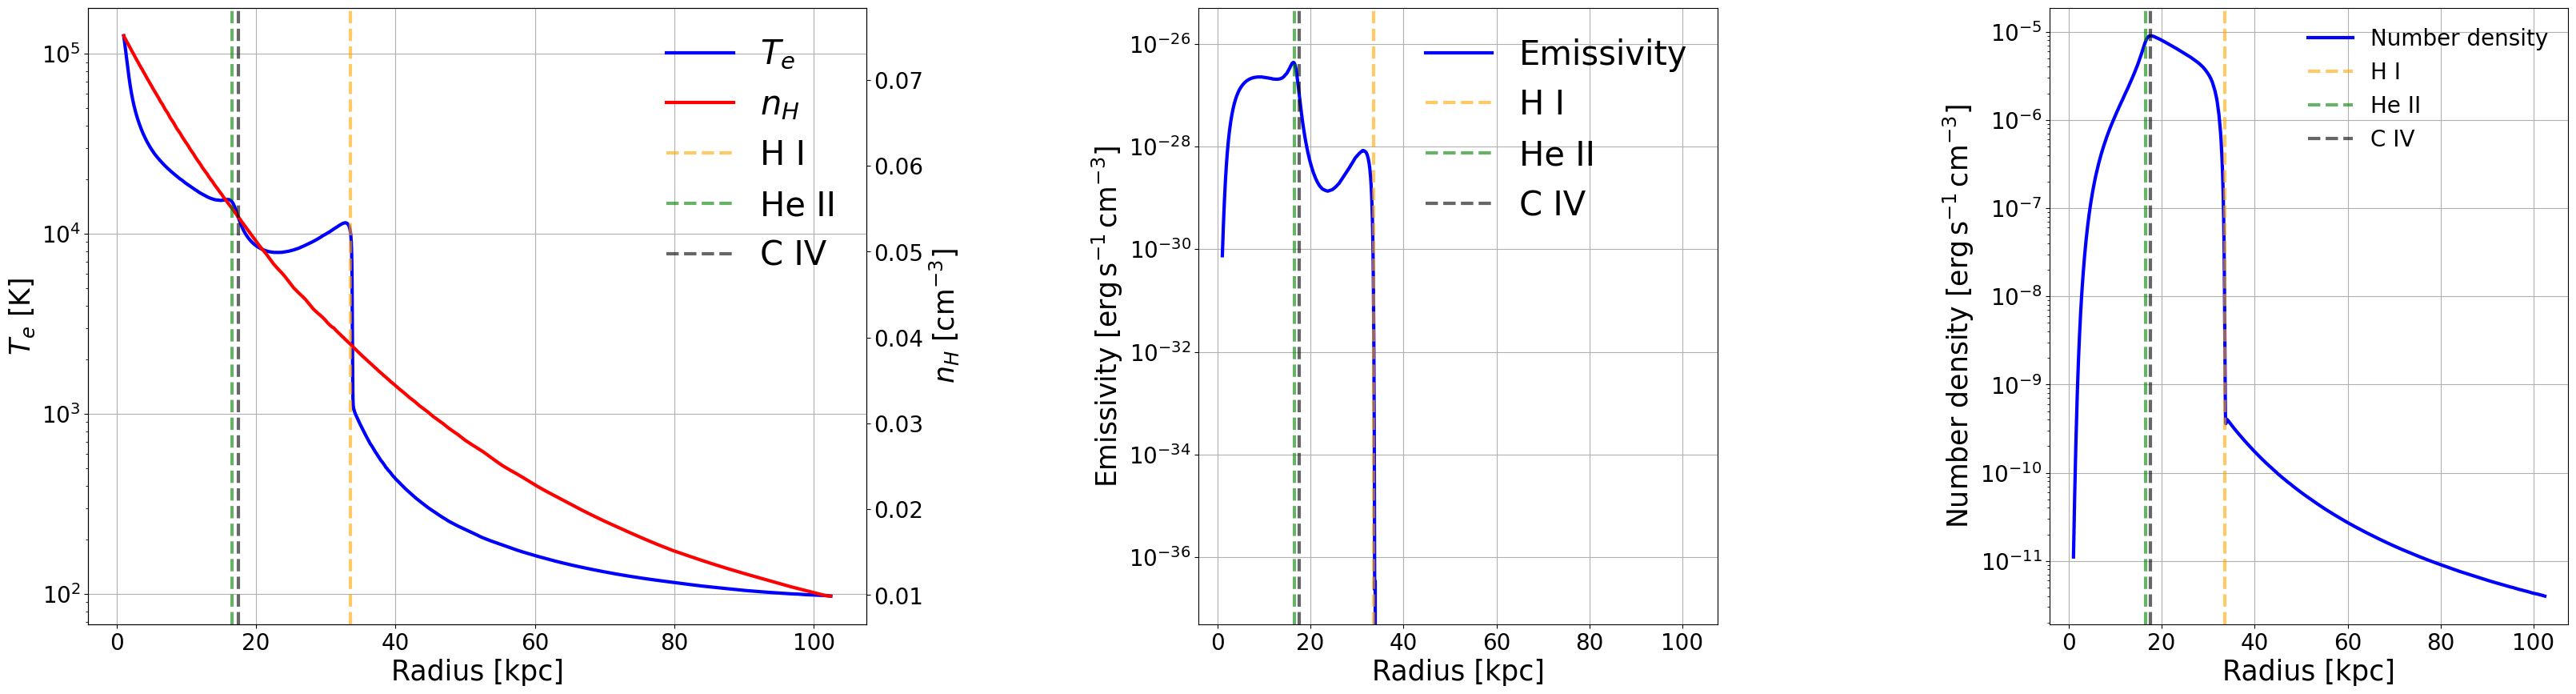

In [30]:
fig = plt.figure(figsize=(40, 10))
gs = gridspec.GridSpec(1, 3, width_ratios=[1.5, 1.0, 1.0], wspace=0.55) 

# width_ratios=[1, 1.2], wspace=0.55

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])



ax1a = ax1
ax1b = ax1a.twinx()

ax1a.plot(output[f'radius_{Lumin}_{idx}'], output[f'Te_{Lumin}_{idx}'], 'b-',lw=3 ,label=r'$T_e$')
ax1b.plot(output[f'radius_{Lumin}_{idx}'], output[f'nH_{Lumin}_{idx}'], 'r-',lw=3 ,label=r'$n_H$')

ax1b.axvline(x=33.5,ymin=0,ymax=1,linestyle='--',color='orange',alpha=0.6,lw=3,label='H I')
ax1b.axvline(x=16.5,ymin=0,ymax=1,linestyle='--',color='g',alpha=0.6,lw=3,label='He II')
ax1b.axvline(x=17.5,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.6,lw=3,label='C IV')

# ax1b.axvline(x=22,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.6,lw=3)

# ax1a.plot(globals()[f'radius_{Lumin}_{version}'], globals()[f'emis_HeII_{Lumin}_{version}'], 'k-',lw=3 ,label=r'Emissivity') # , $\epsilon_{\rm CIV}$
# ax1b.plot(globals()[f'radius_{Lumin}_{version}'], globals()[f'nden_HeII_{Lumin}_{version}'], 'k--', lw=3, label=r'Number density')


ax1a.grid(True)

ax1a.set_xlabel('Radius [kpc]', fontsize=25)
ax1a.set_ylabel(r'$T_e$ [K]', fontsize=25)
ax1b.set_ylabel(r'$n_H$ [$\rm cm^{-3}$]', fontsize=25)

ax1a.set_yscale('log')
# ax1b.set_yscale('log')

ax1a.tick_params(axis='both', labelsize=20)
ax1b.tick_params(axis='both', labelsize=20)
# ax1.set_ylim(5e-38,5e-26)
# ax1b.set_ylim(5e-14,5e-5)
# 범례 통합
lines1, labels1 = ax1a.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=30, frameon=False)

plt.tight_layout()




ax2.plot(output[f'radius_{Lumin}_{idx}'], output[f'emis_CIV_{Lumin}_{idx}'], 'b-',lw=3 ,label=r'Emissivity') # , $\epsilon_{\rm CIV}$


ax2.axvline(x=33.5,ymin=0,ymax=1,linestyle='--',color='orange',alpha=0.6,lw=3,label='H I')
ax2.axvline(x=16.5,ymin=0,ymax=1,linestyle='--',color='g',alpha=0.6,lw=3,label='He II')
ax2.axvline(x=17.5,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.6,lw=3,label='C IV')

# ax2.axvline(x=22,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.6,lw=3)
# ax1a.plot(globals()[f'radius_{Lumin}_{version}'], globals()[f'emis_HeII_{Lumin}_{version}'], 'k-',lw=3 ,label=r'Emissivity') # , $\epsilon_{\rm CIV}$
# ax1b.plot(globals()[f'radius_{Lumin}_{version}'], globals()[f'nden_HeII_{Lumin}_{version}'], 'k--', lw=3, label=r'Number density')


ax1.grid(True)

ax2.set_xlabel('Radius [kpc]', fontsize=25)
ax2.set_ylabel(r'Emissivity [$\rm erg \, s^{-1} \,cm^{-3}$]', fontsize=25)
ax2.set_yscale('log')
ax2.tick_params(axis='both', labelsize=20)
ax2.set_ylim(5e-38,5e-26)
ax2.legend(fontsize=30, frameon=False)

ax2.grid(True)




ax3.plot(output[f'radius_{Lumin}_{idx}'], output[f'nden_CIV_{Lumin}_{idx}'], 'b-',lw=3 ,label=r'Number density') # , $\epsilon_{\rm CIV}$

ax3.axvline(x=33.5,ymin=0,ymax=1,linestyle='--',color='orange',alpha=0.6,lw=3,label='H I')
ax3.axvline(x=16.5,ymin=0,ymax=1,linestyle='--',color='g',alpha=0.6,lw=3,label='He II')
ax3.axvline(x=17.5,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.6,lw=3,label='C IV')

ax3.set_xlabel('Radius [kpc]', fontsize=25)
ax3.set_ylabel(r'Number density [$\rm erg \, s^{-1} \,cm^{-3}$]', fontsize=25)
# ax3.set_ylabel(r'Fraction', fontsize=25)

ax3.set_yscale('log')
ax3.tick_params(axis='both', labelsize=20)

ax3.legend(fontsize=20, frameon=False)
ax3.grid(True)
plt.tight_layout()





plt.tight_layout()

# plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/ttt.png',bbox_inches="tight")

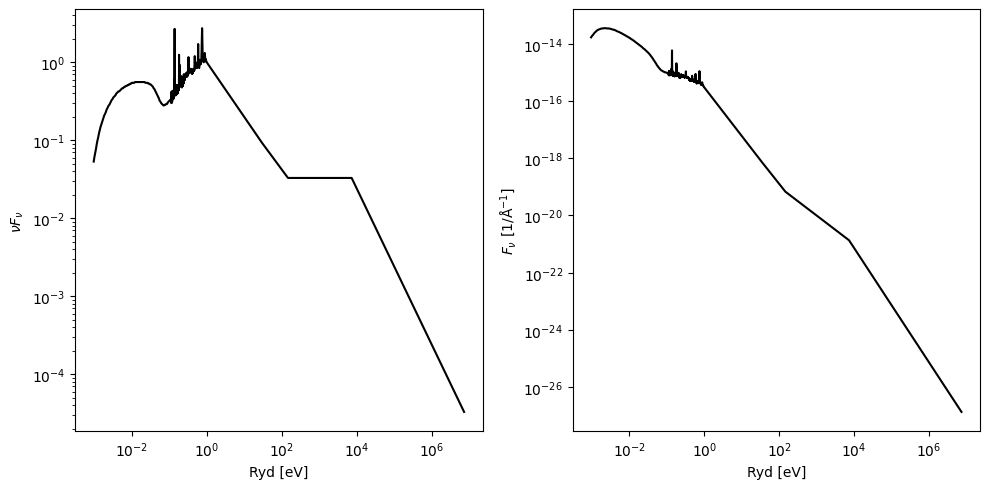

In [66]:
from CLOUDY_Function import QSO_SED

fig = plt.figure(1,figsize=(10,5))

plt.subplot(122)
path_civ = path(Lumin,idx_2,metals,Column_density_order)
x,y =QSO_SED(path_civ)

plt.plot(x,y,'k-',alpha=1)
plt.xscale('log')
plt.yscale('log')

plt.xlabel('Ryd [eV]')
plt.ylabel(r'$F_{\nu}~[\rm 1 / \AA^{-1}]$')

plt.subplot(121)
path_civ = path(Lumin,idx_2,metals,Column_density_order)
x,y =QSO_SED(path_civ)

nu = (x* 13.6/h_ev)
plt.plot(x,y*nu,'k-',alpha=1)
plt.xscale('log')
plt.yscale('log')

plt.xlabel('Ryd [eV]')
plt.ylabel(r'$\nu F_{\nu}$')

plt.tight_layout()

# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/QSO_SED', bbox_inches='tight')

0.7499122169292353 0.7499155525428973


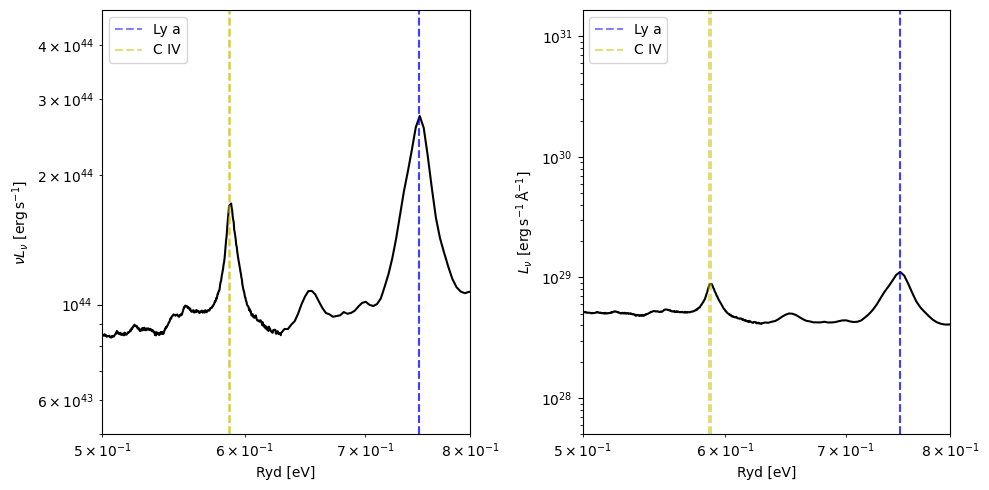

In [67]:
from CLOUDY_Function import QSO_SED

C_IV_K = 1548.187e-8  # cm
C_IV_H = 1550.772e-8  # cm

nu_Lya_K = c_cms / Ly_a_K
nu_Lya_H = c_cms / Ly_a_H

nu_CIV_K = c_cms / C_IV_K 
nu_CIV_H = c_cms / C_IV_H

Ryd_Lya_K = h_ev * nu_Lya_K / 13.6 
Ryd_Lya_H = h_ev * nu_Lya_H / 13.6 

Ryd_CIV_K = h_ev * nu_CIV_K / 13.6 
Ryd_CIV_H = h_ev * nu_CIV_H / 13.6 

print(Ryd_Lya_K, Ryd_Lya_H)

fig = plt.figure(1,figsize=(10,5))

plt.subplot(122)
path_civ = path(Lumin,idx_2,metals,Column_density_order)
x,y =QSO_SED(path_civ)

plt.plot(x,y*1e44,'k-',alpha=1)

plt.axvline(x=Ryd_Lya_K,ymin=0,ymax=1,color='b',linestyle='--',alpha=0.5,label='Ly a')
plt.axvline(x=Ryd_Lya_H,ymin=0,ymax=1,color='b',linestyle='--',alpha=0.5)

plt.axvline(x=Ryd_CIV_K,ymin=0,ymax=1,color='y',linestyle='--',alpha=0.5,label='C IV')
plt.axvline(x=Ryd_CIV_H,ymin=0,ymax=1,color='y',linestyle='--',alpha=0.5)


plt.xscale('log')
plt.yscale('log')

plt.xlim(0.5,0.8)
plt.ylim(ymin=5e-17*1e44)

plt.xlabel('Ryd [eV]')
plt.ylabel(r'$L_{\nu}~[\rm erg \, s^{-1} \,  \AA^{-1}]$')
plt.legend()

plt.subplot(121)
path_civ = path(Lumin,idx_2,metals,Column_density_order)
x,y =QSO_SED(path_civ)

nu = (x* 13.6/h_ev)
plt.plot(x,y*nu*1e44,'k-',alpha=1)

plt.axvline(x=Ryd_Lya_K,ymin=0,ymax=1,color='b',linestyle='--',alpha=0.5,label='Ly a')
plt.axvline(x=Ryd_Lya_H,ymin=0,ymax=1,color='b',linestyle='--',alpha=0.5)

plt.axvline(x=Ryd_CIV_K,ymin=0,ymax=1,color='y',linestyle='--',alpha=0.5,label='C IV')
plt.axvline(x=Ryd_CIV_H,ymin=0,ymax=1,color='y',linestyle='--',alpha=0.5)

plt.xscale('log')
plt.yscale('log')

plt.xlim(0.5,0.8)
plt.ylim(ymin=0.5*1e44)

plt.xlabel('Ryd [eV]')
plt.ylabel(r'$\nu L_{\nu}~[\rm erg \, s^{-1}]$')

plt.tight_layout()

plt.legend()
# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/QSO_SED_CIV_Lya_norm', bbox_inches='tight')

In [96]:
def Flux(Fc,F_max,lam,lam_c,sig_vel):
    del_lam = sig_vel / c_kms  * lam_c
    Flux = (F_max-Fc)*np.exp(- (lam-lam_c)**2 / del_lam**2) + Fc
    return Flux
def EW(Fc,F_max,lam_c,sig_vel):
    del_lam = sig_vel / c_kms  * lam_c
    # print('dlam',del_lam)
    EW =(F_max/ Fc)*np.sqrt(np.pi)*del_lam
    return EW

def Ryd_to_lam(Ryd_x):
    lambda_x = c_cms /  (Ryd_x * 13.6 /h_ev) *1e8

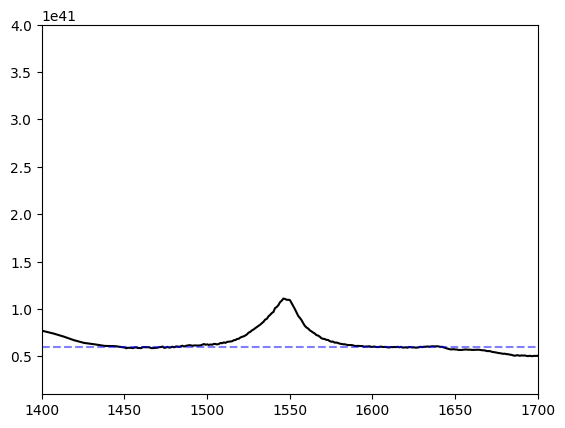

In [115]:
Ryd, Fnu = QSO_SED(path = path(Lumin,2,metals,Column_density_order)) # [1/Hz]
nu = (Ryd * 13.6 /h_ev) # 1/s = Hz
nuFnu = Fnu * nu # dimenionless parameter 
normalized_factor = 10**(Lumin)/nuFnu[np.where(Ryd==1)[0]] # erg/s

Lnu = Fnu*normalized_factor # erg/s/Hz
nuLnu = Fnu*normalized_factor*nu # erg/s

lambda_x = c_cms /  (Ryd * 13.6 /h_ev)   # cm
ii = np.where((lambda_x >1400e-8) & (lambda_x <= 1700e-8))[0]

Llambda= Lnu* c_cms / (lambda_x)**2 *1e-8  # erg/s/A

plt.plot(lambda_x*1e8, Llambda,'k-',label='QSO SED')
plt.xlim(1400,1700)
plt.ylim(ymin=0.1e41,ymax=4e41)
# plt.yscale('log')

Lc = 6e40
plt.axhline(y=Lc,xmin=0,xmax=1,color='b',linestyle='--',alpha=0.5,label='Continuum')

# aa = np.argmax(Llambda[ii])
# Llambda_max = Llambda[ii[aa]] 
# lambda_c = lambda_x[ii[aa]]
# nu_c = c_cms / lambda_x[ii[aa]] 

# sig_vel = 3000
# flux = Flux(Lc,Llambda_max,lambda_x,lambda_c,sig_vel)
# ew = EW(Lc,Llambda_max,lambda_c,sig_vel)
# # print(ew , lambda_c)

# print(f'Equivalent Width = {ew*1e8:.2f} Angstrom')
# print(f'Total Luminosity = {ew*Lc:.2e} erg/s') 
# CIV_total_flux_QSO = ew*Lc #* nu_c

# plt.plot(lambda_x*1e8,flux,'r--',label='Fitting')

# print(Llambda_max)


# plt.xscale('log')
# plt.yscale('log')

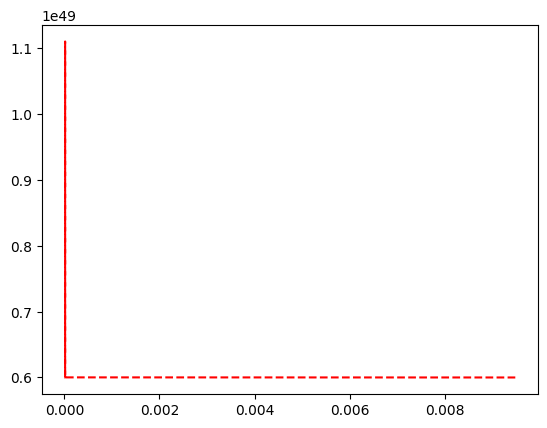

In [ ]:

plt.plot(lambda_x,flux,'r--',label='Fitting')
plt.
# plt.xlim(1400,1700)
# plt.ylim(ymin=0.1e48,ymax=4e49)